# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

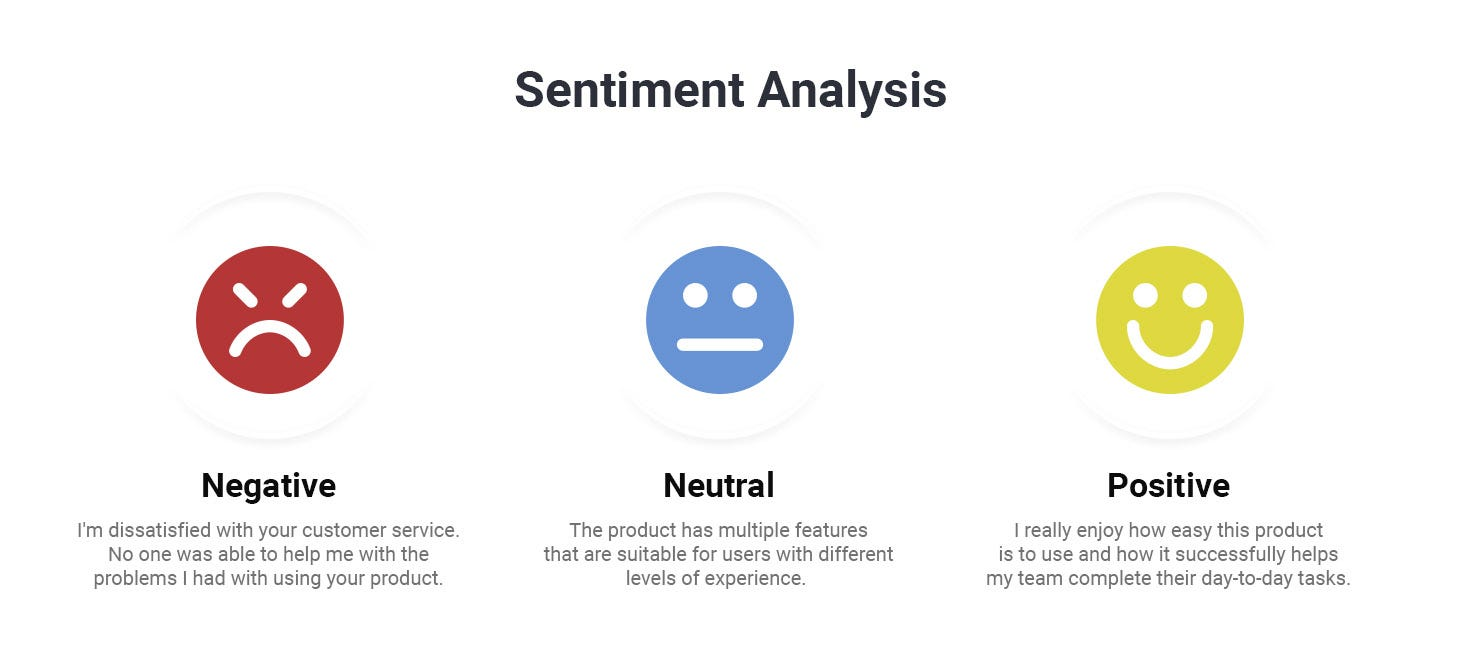

# Disneyland Reviews Dataset
In this lab we'll look into Disneyland Reviews dataset.  
*Link: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews*

The dataset includes 42,000 reviews of 3 Disneyland branches - Paris, California and Hong Kong, posted by visitors on Trip Advisor.

Column Description:

- Review_ID: unique id given to each review
- Rating: ranging from 1 (unsatisfied) to 5 (satisfied)
- Year_Month: when the reviewer visited the theme park
- Reviewer_Location: country of origin of visitor
- Review_Text: comments made by visitor
- Disneyland_Branch: location of Disneyland Park

In [ ]:
# Load the dataset
import pandas as pd

data = pd.read_csv('/content/DisneylandReviews.csv', encoding='latin-1')
data

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong
...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris


In [ ]:
#Check for missing values
data.isna().sum()

,0
Review_ID,0
Rating,0
Year_Month,0
Reviewer_Location,0
Review_Text,0
Branch,0


In [ ]:
# Drop rows with missing values in the relevant columns
data = data.dropna(subset=['Review_Text', 'Rating'])

In [ ]:
# Map star ratings to sentiments
data['Sentiment'] = data['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))
data.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,Sentiment
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,positive
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,positive
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,positive
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,positive
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,positive


In [ ]:
# Import necessary libraries
import re
import nltk

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize the text
    words = text.split()

    return ' '.join(words)

# Apply preprocessing to the review text
data['Review_Text'] = data['Review_Text'].apply(preprocess_text)

# Display cleaned reviews
data[['Review_Text', 'Sentiment']].head()

,Review_Text,Sentiment
0,if youve ever been to disneyland anywhere youl...,positive
1,its been a while since d last time we visit hk...,positive
2,thanks god it wasn t too hot or too humid when...,positive
3,hk disneyland is a great compact park unfortun...,positive
4,the location is not in the city took around ho...,positive


In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the dataset into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(data['Review_Text'], data['Sentiment'], test_size=0.2, random_state=42)


# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # You can adjust max_features based on your dataset size - limit vocabulary to the 1000 most informative tokens
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

In [ ]:
print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

train_data size: (34124,)
test_data size: (8532,)


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train the Support Vector Machine (SVM) classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(train_vectors, train_labels)

# Predictions on the test set
predictions = svm_classifier.predict(test_vectors)

# Evaluate the model
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))


Accuracy: 0.84
Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.54      0.58       720
     neutral       0.48      0.18      0.26      1035
    positive       0.88      0.98      0.92      6777

    accuracy                           0.84      8532
   macro avg       0.66      0.56      0.59      8532
weighted avg       0.81      0.84      0.81      8532



# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluation the model on the Test Set

Task6: Print the Confusion Matrix

## Task1: Load the data and do 5 different preprocessing steps on it

In [1]:
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Load the dataset
data = pd.read_csv(r'archive (4)\Amazon_Unlocked_Mobile.csv')

# Remove rows with missing reviews or ratings
data = data.dropna(subset=['Reviews', 'Rating'])

# Convert ratings into sentiment labels
data['Sentiment'] = data['Rating'].apply(
    lambda rating: 'positive' if rating > 3
    else ('negative' if rating < 3 else 'neutral')
)

stop_words = set(stopwords.words('english'))

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Remove punctuation, numbers, and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Tokenize the text
    words = word_tokenize(text)

    # 5. Remove stop words
    words = [word for word in words if word not in stop_words]

    return ' '.join(words)

# Apply preprocessing
data['Cleaned_Reviews'] = data['Reviews'].apply(preprocess_text)

# Display the results
data[['Reviews', 'Cleaned_Reviews', 'Rating', 'Sentiment']].head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\janah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\janah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\janah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Reviews,Cleaned_Reviews,Rating,Sentiment
0,I feel so LUCKY to have found this used (phone...,feel lucky found used phone us used hard phone...,5,positive
1,"nice phone, nice up grade from my pantach revu...",nice phone nice grade pantach revue clean set ...,4,positive
2,Very pleased,pleased,5,positive
3,It works good but it goes slow sometimes but i...,works good goes slow sometimes good phone love,4,positive
4,Great phone to replace my lost phone. The only...,great phone replace lost phone thing volume bu...,4,positive


## Task2: Use a proper train and test split

In [2]:
from sklearn.model_selection import train_test_split

train_data, test_data, train_labels, test_labels = train_test_split(
    data['Cleaned_Reviews'],
    data['Sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=data['Sentiment']
)

print("Training data size:", train_data.shape)
print("Testing data size:", test_data.shape)

Training data size: (331016,)
Testing data size: (82754,)


## Task3: Do Feature Extraction Using TF-IDF

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=1000)

# Learn from and transform the training data
train_vectors = tfidf_vectorizer.fit_transform(train_data)

# Transform the testing data
test_vectors = tfidf_vectorizer.transform(test_data)

print("Training vectors shape:", train_vectors.shape)
print("Testing vectors shape:", test_vectors.shape)

Training vectors shape: (331016, 1000)
Testing vectors shape: (82754, 1000)


## Task4: Train a Naive Bayes Classifier

In [4]:
from sklearn.naive_bayes import MultinomialNB

# Create the Naive Bayes classifier
nb_classifier = MultinomialNB()

# Train the classifier
nb_classifier.fit(train_vectors, train_labels)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


## Task5: Evaluation the model on the Test Set

In [5]:
from sklearn.metrics import accuracy_score, classification_report

# Predict the sentiment of the test data
predictions = nb_classifier.predict(test_vectors)

# Calculate accuracy
accuracy = accuracy_score(test_labels, predictions)

print(f"Accuracy: {accuracy:.4f}")

# Print precision, recall, and F1-score
print("\nClassification Report:")
print(classification_report(test_labels, predictions, zero_division=0))

Accuracy: 0.8269

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.68      0.73     19412
     neutral       0.32      0.02      0.04      6352
    positive       0.84      0.97      0.90     56990

    accuracy                           0.83     82754
   macro avg       0.65      0.56      0.56     82754
weighted avg       0.79      0.83      0.79     82754



## Task6: Print the Confusion Matrix

Confusion Matrix:
[[13179    75  6158]
 [ 1882   134  4336]
 [ 1664   208 55118]]


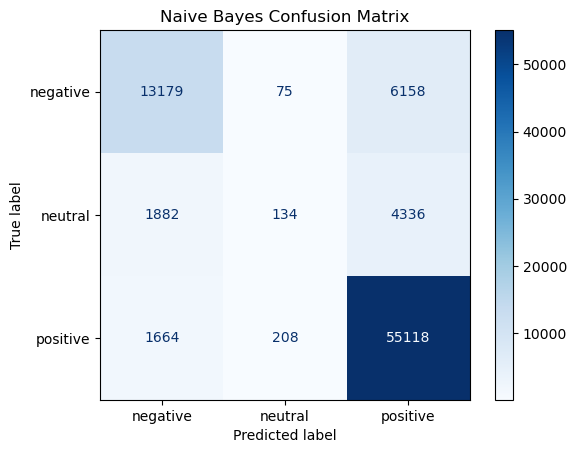

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(
    test_labels,
    predictions,
    labels=nb_classifier.classes_
)

print("Confusion Matrix:")
print(cm)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=nb_classifier.classes_
)

disp.plot(cmap='Blues')
plt.title('Naive Bayes Confusion Matrix')
plt.show()